In [48]:
import numpy as np
from behavior_models import models
from one.api import ONE
from brainbox.io.one import SessionLoader
import pandas as pd
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
import pickle as pkl

from ibl_info.broja_pid import compute_pid, coinformation, compute_pid_unbiased, unbiasedMI, MI
from idtxl.bivariate_mi import BivariateMI
from idtxl.bivariate_te import BivariateTE
from prior_localization.functions.behavior_targets import optimal_Bayesian
from tqdm import tqdm
import itertools
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import seaborn as sns


In [178]:
def discretize_hidden_state(hidden_state, n_bins=15):
    """
    Discretize the hidden state into equipopulated bins

    Args:
        hidden_state (np.array): activations for neurons x trials
        method (str, optional): how to determine the percenille. 
                                Defaults to 'neuron'. Calculate the percentile per neuron
                                Other options: 'all': Calculate the percentile based on the entire dataset
    """
    
    
    discrete_data = np.zeros((hidden_state.shape[0], hidden_state.shape[1]))
    # discretize per recorded neuron
    for idx in tqdm(range(hidden_state.shape[0])):

        row = hidden_state[idx, :]
        #bin_edges = np.percentile(row, [20,40,60,80])
        # set bin edges to 4 parts
        #bin_edges = np.percentile(row, [25,50,75])
        #discrete_data[idx, :] = np.digitize(row, bin_edges)
        discrete_row, bin_edges_p = pd.qcut(row, q=n_bins, labels=False, duplicates='drop', retbins=True)
        discrete_data[idx, :] = discrete_row
    
    discrete_data = np.nan_to_num(discrete_data, nan=0)
    return discrete_data

In [5]:
def generate_source_ids(number_of_neurons):
    combinations_neuronids=[]
    for x in itertools.combinations(range(number_of_neurons), 2):
        combinations_neuronids.append([x[0], x[1]])
    
    combinations_neuronids = np.asarray(combinations_neuronids)
    return combinations_neuronids


In [6]:
def compute_information_decomposition(decoding_variable, neural_data):
    # always same region
    # neural data is in neurons x trials
    targets = decoding_variable
    sources = generate_source_ids(neural_data.shape[0])

    pid_information = np.zeros((len(sources), 4)) # neuronsC2 x 4
    coinformation_data = np.zeros((len(sources), 4)) # neuronsC2 x 4

    for idx in tqdm(range(len(sources)), desc="Running for all sources",leave=False):
        s1 = sources[idx][0]
        s2 = sources[idx][1]
        X1 = np.asarray(neural_data[s1, :], dtype=np.int32)
        X2 = np.asarray(neural_data[s2, :], dtype=np.int32)
        Y = np.asarray(targets, dtype=np.int32)
        u1, u2, red, syn = compute_pid_unbiased(Y, X1, X2)
        coinfo, mi_yx1x2, mi_yx1, mi_yx2 = coinformation(Y, X1, X2)
        pid_information[idx, :] = u1, u2, red, syn
        coinformation_data[idx,:] = mi_yx1, mi_yx2, coinfo, mi_yx1x2


    # now to organize this?
    # nah, unique information would just be the mean of the first two
    # red and syn  are fine
    # yx1 and yx2 mutual info are also similar to UI
    # the other two are trivariate

    return pid_information, coinformation_data

In [80]:
def find_optimal_discretization_kfold(X, Y, max_bins=20, n_folds=5, random_state=42):
    """
    Find optimal discretization for multiple features.
    
    Parameters:
    -----------
    X : array-like of shape (n_timepoints, n_neurons)
        Input features to be discretized
    Y : array-like of shape (n_timepoints, )
        Target variable
    max_bins : int, default=20
        Maximum number of bins to consider
    n_folds : int, default=5
        Number of folds
    random_state : int, default=42
        Random seed for reproducibility
    
    Returns:
    --------
    dict : A dictionary containing:
        - 'optimal_bins': List of optimal bin counts for each feature
        - 'mutual_info_scores': List of mutual information scores for each feature
        - 'full_dataset_mi': Mutual information computed on full dataset for each feature
    """
    # Flatten Y if it's a 2D array
    Y = Y.ravel()
    
    # Ensure X is 2D
    
    
    # Split the data into subset for bin optimization and full dataset
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    mi_fold_test = []
    mi_fold_train = []
    optimal_bin_list = []
    for fold_idx, (train_idx, val_idx) in tqdm(enumerate(kf.split(X))):
        X_train, X_val = X[train_idx,:], X[val_idx,:]
        y_train, y_val = Y[train_idx], Y[val_idx]
        mi_scores_list = []
        mi_train_per_cv_loop = []
        
        # discretize X_train first, try different bin sizes
        for n_bins in range(2, max_bins + 1):
            discretizer = KBinsDiscretizer(
                    n_bins=n_bins, 
                    encode='ordinal', 
                    strategy='quantile'
                )
            # this discretizes each feature by itself
            discretized_X_subset = discretizer.fit_transform(X_train)
            mi_scores = []       
            for feature_idx in range(X.shape[1]):
        
                X_subset_feature = discretized_X_subset[:, feature_idx]
                # Store MI scores for different bin counts
                            
                # Calculate mutual information on subset
                mi_scores.append(MI(X_subset_feature, y_train))
            
            mi_scores = np.asarray(mi_scores) # the idea is to find the best discretization for all features
            mi_scores_list.append(np.mean(mi_scores))
            
            mi_train_per_cv_loop.append(mi_scores) # mi_score -> numberoffeatures x 1, bins
        mi_fold_train.append(np.asarray(mi_train_per_cv_loop))

    
        # Find the optimal number of bins from subset
        optimal_bins = np.argmax(mi_scores_list) + 2  # +2 because we started from 2 bins
        
        # Compute mutual information on full dataset with optimal bins
        full_discretizer = KBinsDiscretizer(
                n_bins=optimal_bins, 
                encode='ordinal', 
                strategy='quantile'
            )
        optimal_bin_list.append(optimal_bins)
        X_full_discretized = full_discretizer.fit_transform(X_val)
        mi_test_scores = []
        for feature_idx in range(X.shape[1]):
            mi_test_scores.append(MI(X_full_discretized[:,feature_idx], y_val))

        mi_fold_test.append(mi_test_scores)


    return np.asarray(mi_fold_train), np.asarray(mi_fold_test), np.asarray(optimal_bin_list)

In [144]:
#setup data
def load_data(model_name):
    with open(f'../models/{model_name}.pkl','rb') as f:
        trained_model = pkl.load(f)

        
    # stimulus values plot and rnn-action taken
    session_data = trained_model['session_data']

    action_data = session_data.loc[
        session_data['action_taken'] == 1,
        ['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
    action_data['signed_trial_strength'] /= action_data['signed_trial_strength'].max()
    

    t_end = session_data.loc[session_data['action_taken'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index']]
    t_end['signed_trial_strength'] /= t_end['signed_trial_strength'].max()

    # stimulus values plot and rnn-action taken
    signal = optimal_Bayesian(act=t_end['action_side'].values, side=t_end['trial_side'].values)
    bayes_signal = np.asarray(signal.data.numpy()>=0.5, dtype=int)
    action_data['opt_bayesian'] = bayes_signal
    t_0 = session_data.loc[session_data['trial_start'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index','concordant_trial']]
    t_0['signed_trial_strength'] /= t_0['signed_trial_strength'].max()

    t_end = session_data.loc[session_data['action_taken'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index','concordant_trial']]
    t_end['signed_trial_strength'] /= t_end['signed_trial_strength'].max()
    t_end['Bayes'] = bayes_signal

    iloc = np.where((session_data['action_taken'] == 1)==True)[0]
    t_1 = session_data.iloc[iloc-1][['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus','rnn_step_index','concordant_trial']]
    t_1['action_side'] = t_end['action_side'].values
    t_1['Bayes'] = bayes_signal
    t_1_non_zero = t_1.loc[(t_1['right_stimulus']!=0) | (t_1['left_stimulus']!=0) ]


    # now for t_end for zero contrast trials, split by correct and incorrect choices
    t_zero_contrast = t_end[t_end['signed_trial_strength']==0]

    # find correct and incorrect indices

    hidden_state_t_0 = np.concatenate(t_0['hidden_state'].values)
    hidden_state_t_1 = np.concatenate(t_1['hidden_state'].values)
    hidden_state_t_1_non_zero = np.concatenate(t_1_non_zero['hidden_state'].values)
    hidden_state_t_end = np.concatenate(t_end['hidden_state'].values)
    hidden_state_t_zero_contrast = np.concatenate(t_zero_contrast['hidden_state'].values)

    return t_0, t_1, t_end, t_1_non_zero, t_zero_contrast, hidden_state_t_0, hidden_state_t_1, hidden_state_t_1_non_zero, hidden_state_t_end, hidden_state_t_zero_contrast, session_data, action_data





In [145]:
t_0_og, t_1_og, t_end_og, t_1_non_zero_og, t_zero_contrast_og, hidden_state_t_0_og, hidden_state_t_1_og, hidden_state_t_1_non_zero_og, hidden_state_t_end_og, hidden_state_t_zero_contrast_og, session_data_og,action_data_og = load_data('rnn_ann_model_results')

5it [00:22,  4.53s/it]


Text(0.5, 1.0, 'MI , hidden state vs action')

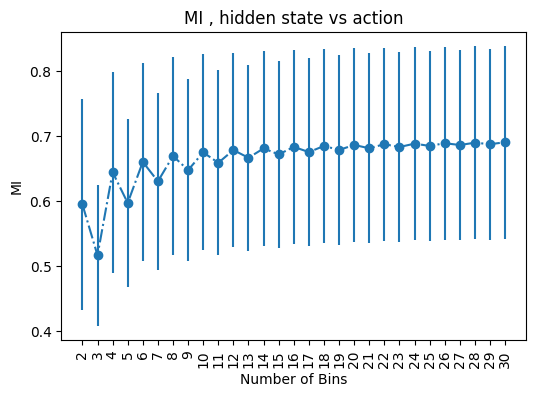

In [84]:
# i can use the mi_fold_train to plot the optimal values
target = t_end['action_side'].values
train_scores, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target, max_bins=30)

train_scores_averaged = np.mean(train_scores, axis=(0,2))
train_scores_std = np.std(train_scores, axis=(0,2))

fig, ax = plt.subplots(figsize=(6,4))
plt.errorbar(np.arange(train_scores.shape[1]), train_scores_averaged,marker='o',yerr=train_scores_std/2,linestyle='-.')
plt.ylabel('MI')
plt.xlabel('Number of Bins')
plt.title('Optimal number of bins')
plt.xticks(np.arange(train_scores.shape[1]), np.arange(train_scores.shape[1])+2, rotation=90)
plt.title('MI , hidden state vs action')

In [ ]:
# then all the analysis on the newer model

# pid and also mutual information, also with stimulus strength; discretize stimulus strength into 6 bins
# reaction time proxy
# same plot for 10 neurons

In [213]:
t_0, t_1, t_end, t_1_non_zero, t_zero_contrast, hidden_state_t_0, hidden_state_t_1, hidden_state_t_1_non_zero, hidden_state_t_end, hidden_state_t_zero_contrast, session_data,action_data = load_data('rnn_ann_model_results_10units_100000')

5it [00:04,  1.15it/s]


Text(0.5, 1.0, 'MI , hidden state vs action')

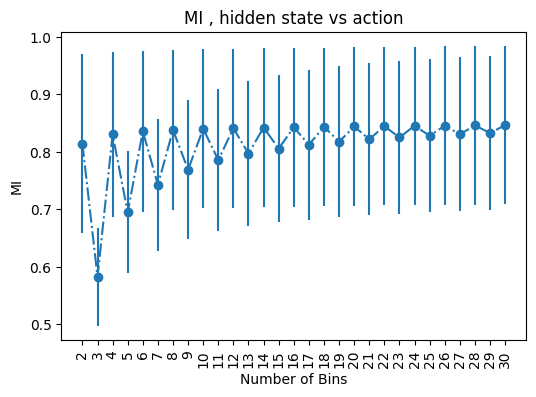

In [181]:
# i can use the mi_fold_train to plot the optimal values
target = t_end['action_side'].values
train_scores, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target, max_bins=30)

train_scores_averaged = np.mean(train_scores, axis=(0,2))
train_scores_std = np.std(train_scores, axis=(0,2))

fig, ax = plt.subplots(figsize=(6,4))
plt.errorbar(np.arange(train_scores.shape[1]), train_scores_averaged,marker='o',yerr=train_scores_std/2,linestyle='-.')
plt.ylabel('MI')
plt.xlabel('Number of Bins')
plt.title('Optimal number of bins')
plt.xticks(np.arange(train_scores.shape[1]), np.arange(train_scores.shape[1])+2, rotation=90)
plt.title('MI , hidden state vs action')

In [214]:
# okay, now previous analysis; for all the conditions


# this is correct, we can use the bayes idx to subset the prior signal

incorrect_zero_contrast = session_data.loc[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==0) & (session_data['trial_strength']==0)].index
correct_zero_contrast = session_data.loc[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==1) & (session_data['trial_strength']==0)].index

bayes_idx_correct_zero_contrast = np.concatenate([np.where(t_end.index == value)[0] for value in correct_zero_contrast])
bayes_idx_incorrect_zero_contrast = np.concatenate([np.where(t_end.index == value)[0] for value in incorrect_zero_contrast])



# this is for the traditional, correct vs incorrect actions

correct_trials = session_data[(session_data['correct_trial_dt']==1)]
incorrect_trials = session_data[(session_data['correct_trial_dt']==0)]

bayes_indices_correct = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==1)].index]).reshape(-1,)
bayes_indices_incorrect = np.asarray([session_data[(session_data['action_taken']==1) & (session_data['correct_trial_dt']==0)].index]).reshape(-1,)

bayes_idx_correct = np.concatenate([np.where(action_data.index == value)[0] for value in bayes_indices_correct])
bayes_idx_incorrect = np.concatenate([np.where(action_data.index == value)[0] for value in bayes_indices_incorrect])


In [253]:
t_0

,block_side,signed_trial_strength,action_side,trial_side,correct_action_taken,hidden_state,left_stimulus,right_stimulus,rnn_step_index,concordant_trial
0,1.0,0.600098,NaN,1.0,NaN,"[[-0.09714925324303937, 0.15102554104252375, -...",0.0,0.0,0.0,True
3,1.0,0.000000,NaN,1.0,NaN,"[[-0.7869296420622923, 0.04123891251973749, -0...",0.0,0.0,0.0,True
9,1.0,0.399902,NaN,1.0,NaN,"[[-0.5916082280689903, -0.1372081009977152, -0...",0.0,0.0,0.0,True
12,1.0,0.199951,NaN,1.0,NaN,"[[-0.8803824618061681, 0.06372312229416466, -0...",0.0,0.0,0.0,True
15,1.0,0.600098,NaN,1.0,NaN,"[[-0.7872749286304555, -0.23973440159988765, -...",0.0,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...
16307,-1.0,-0.199951,NaN,-1.0,NaN,"[[0.7692409412351647, 0.571926209119692, 0.233...",0.0,0.0,0.0,True
16311,-1.0,-0.000000,NaN,-1.0,NaN,"[[0.8265221159417121, 0.5400893749003923, 0.30...",0.0,0.0,0.0,True
16314,-1.0,-0.600098,NaN,-1.0,NaN,"[[0.7785150245451719, 0.5853242388970838, 0.27...",0.0,0.0,0.0,True
16317,-1.0,-0.600098,NaN,-1.0,NaN,"[[0.8211301895173099, 0.49631042563655325, 0.2...",0.0,0.0,0.0,True


<Axes: >

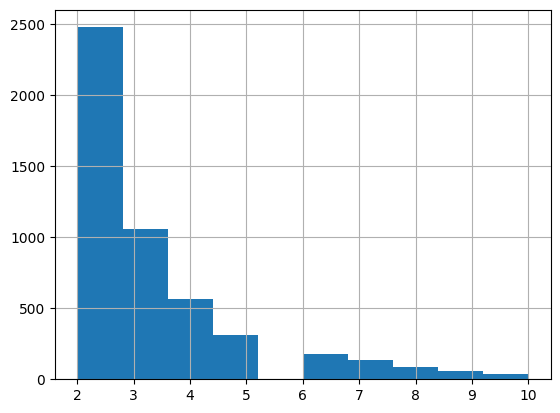

In [208]:
t_end['rnn_step_index'].hist()

In [201]:
session_data

,rnn_step_within_session,trial_within_session,block_index,trial_index,rnn_step_index,block_side,trial_side,trial_strength,trial_start,trial_end,...,action_side,correct_action_taken,session_index,1_back_correct,2_back_correct,3_back_correct,signed_trial_strength,concordant_trial,correct_trial_dt,trial_side_orthogonal
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.5,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,1.5,True,1.0,0.429688
1,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,1.5,True,1.0,0.429688
2,2.0,0.0,0.0,0.0,2.0,1.0,1.0,1.5,NaN,1.0,...,1.0,1.0,0,NaN,NaN,NaN,1.5,True,1.0,0.429688
3,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.0,True,0.0,0.429688
4,4.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,0.0,True,0.0,0.429688
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21676,21680.0,5012.0,99.0,31.0,1.0,-1.0,-1.0,1.5,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,-1.5,True,1.0,-0.429688
21677,21680.0,5012.0,99.0,31.0,2.0,-1.0,-1.0,1.5,NaN,1.0,...,-1.0,1.0,0,1.0,1.0,1.0,-1.5,True,1.0,-0.429688
21678,21680.0,5012.0,99.0,32.0,0.0,-1.0,1.0,2.0,1.0,NaN,...,NaN,NaN,0,NaN,NaN,NaN,2.0,False,1.0,1.570312
21679,21680.0,5012.0,99.0,32.0,1.0,-1.0,1.0,2.0,NaN,NaN,...,NaN,NaN,0,NaN,NaN,NaN,2.0,False,1.0,1.570312


In [183]:

print('choice representation')
target = t_end['action_side'].values
_, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target)

_, test_scores_action_fold_t0, optimal_bins_t0_action = find_optimal_discretization_kfold(hidden_state_t_0, target)

print('stimulus representation')
target = t_end['trial_side'].values
_, test_scores_trial_fold_tend, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_0['trial_side'].values
_, test_scores_trial_fold_t0, optimal_bins_t0_trial = find_optimal_discretization_kfold(hidden_state_t_0, target)


print('prior representation')
target = t_end['Bayes'].values
_, test_scores_bayesian_fold_t0, optimal_bins_t0_bayesian = find_optimal_discretization_kfold(hidden_state_t_0, target)
_, test_scores_bayesian_fold_tend, optimal_bins_tend_bayesian = find_optimal_discretization_kfold(hidden_state_t_end, target)



choice representation


5it [00:02,  1.76it/s]
0it [00:00, ?it/s]


IndexError: index 4900 is out of bounds for axis 0 with size 4900

In [ ]:
k = KBinsDiscretizer(n_bins=6, encode='ordinal')
left_stim_values = k.fit_transform(t_end['left_stimulus'].values.reshape(-1,1))
right_stim_values = k.fit_transform(t_end['right_stimulus'].values.reshape(-1,1))


In [248]:
#stim representation with actual values

k = KBinsDiscretizer(n_bins=6, encode='ordinal')



print('stimulus representation left vs right')
left_stim_values = k.fit_transform(t_zero_contrast['left_stimulus'].values.reshape(-1,1))
right_stim_values = k.fit_transform(t_zero_contrast['right_stimulus'].values.reshape(-1,1))

# target = t_zero_contrast['trial_side'].values
_, test_scores_trial_fold_tend_left, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_zero_contrast, left_stim_values)
_, test_scores_trial_fold_tend_right, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_zero_contrast, right_stim_values)


stimulus representation left vs right


5it [00:00,  7.65it/s]
5it [00:00,  7.85it/s]


In [251]:
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_tend_left, axis=0),np.mean(test_scores_trial_fold_tend_right, axis=0)], axis=1)

Text(0.5, 1.0, '$T_{action}$')

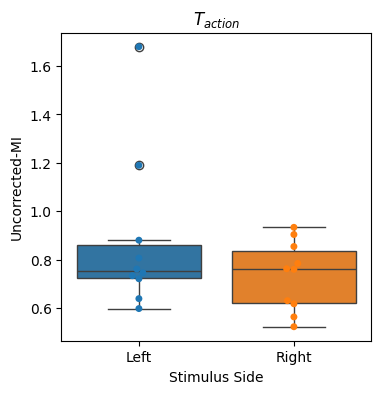

In [252]:
fig, ax = plt.subplots(figsize=(4,4))

sns.boxplot(stimulus_scores)
sns.swarmplot(stimulus_scores)
ax.set_xticks(np.arange(2),labels=['Left','Right'])
ax.set_xlabel('Stimulus Side')
ax.set_ylabel('Uncorrected-MI')
ax.set_title('$T_{action}$')


In [244]:

X = t_zero_contrast[(t_zero_contrast['correct_action_taken']==1) & (t_zero_contrast['action_side']==1)]

#stim representation with actual values

k = KBinsDiscretizer(n_bins=6, encode='ordinal')

print('stimulus representation left vs right')
left_stim_values = k.fit_transform(X['left_stimulus'].values.reshape(-1,1))
right_stim_values = k.fit_transform(X['right_stimulus'].values.reshape(-1,1))
hidden_state_t_right = np.concatenate(X['hidden_state'].values)
# target = t_zero_contrast['trial_side'].values
_, test_scores_trial_fold_tend_left, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_right, left_stim_values)
_, test_scores_trial_fold_tend_right, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_right, right_stim_values)



stimulus representation left vs right


5it [00:00, 14.96it/s]
5it [00:00, 14.63it/s]


Text(0.5, 1.0, '$T_{action}$ when stimulus is on the right, zero contrast')

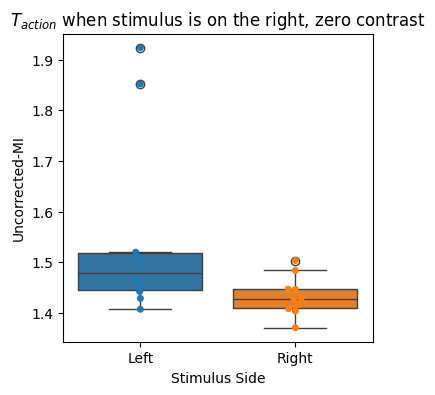

In [245]:
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_tend_left, axis=0),np.mean(test_scores_trial_fold_tend_right, axis=0)], axis=1)
fig, ax = plt.subplots(figsize=(4,4))

sns.boxplot(stimulus_scores)
sns.swarmplot(stimulus_scores)
ax.set_xticks(np.arange(2),labels=['Left','Right'])
ax.set_xlabel('Stimulus Side')
ax.set_ylabel('Uncorrected-MI')
ax.set_title('$T_{action}$ when stimulus is on the right, zero contrast')


In [246]:

X = t_zero_contrast[(t_zero_contrast['correct_action_taken']==1) & (t_zero_contrast['action_side']==-1)]

#stim representation with actual values

k = KBinsDiscretizer(n_bins=6, encode='ordinal')

print('stimulus representation left vs right')
left_stim_values = k.fit_transform(X['left_stimulus'].values.reshape(-1,1))
right_stim_values = k.fit_transform(X['right_stimulus'].values.reshape(-1,1))
hidden_state_t_right = np.concatenate(X['hidden_state'].values)
# target = t_zero_contrast['trial_side'].values
_, test_scores_trial_fold_tend_left, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_right, left_stim_values)
_, test_scores_trial_fold_tend_right, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_right, right_stim_values)



stimulus representation left vs right


5it [00:00, 13.55it/s]
5it [00:00, 15.06it/s]


Text(0.5, 1.0, '$T_{action}$ when stimulus is on the left, zero contrast')

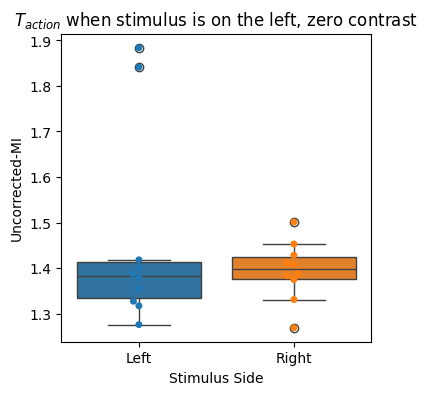

In [247]:
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_tend_left, axis=0),np.mean(test_scores_trial_fold_tend_right, axis=0)], axis=1)
fig, ax = plt.subplots(figsize=(4,4))

sns.boxplot(stimulus_scores)
sns.swarmplot(stimulus_scores)
ax.set_xticks(np.arange(2),labels=['Left','Right'])
ax.set_xlabel('Stimulus Side')
ax.set_ylabel('Uncorrected-MI')
ax.set_title('$T_{action}$ when stimulus is on the left, zero contrast')


Text(0.5, 1.0, 'Choice')

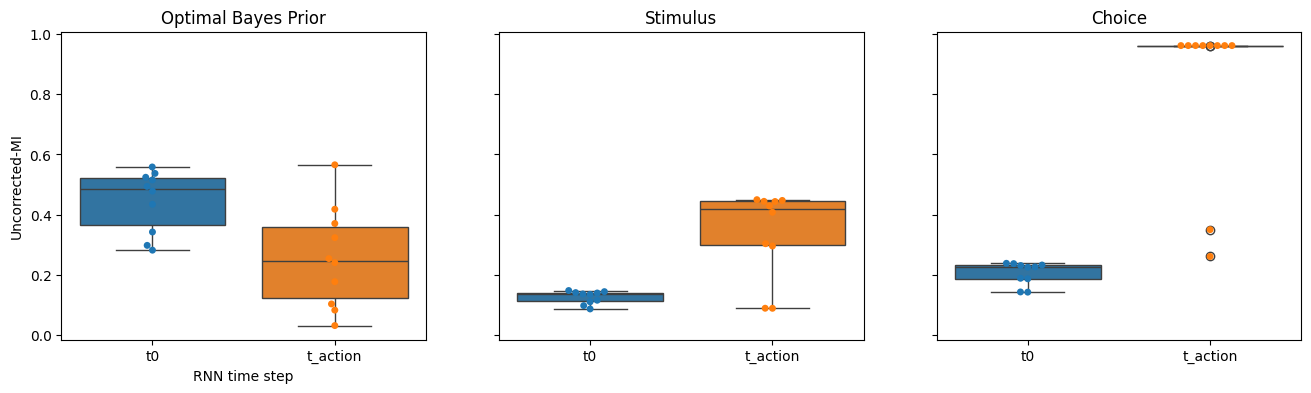

In [184]:
action_scores = np.stack([np.mean(test_scores_action_fold_t0, axis=0),np.mean(test_scores_action_fold_tend, axis=0)], axis=1)
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_t0, axis=0),np.mean(test_scores_trial_fold_tend, axis=0)], axis=1)
bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_t0, axis=0),np.mean(test_scores_bayesian_fold_tend, axis=0)], axis=1)

fig, ax = plt.subplots(ncols=3, figsize=(16, 4), sharey=True, sharex=True)

sns.boxplot(bayesian_scores,ax=ax[0])
sns.swarmplot(bayesian_scores,ax=ax[0])

sns.boxplot(stimulus_scores,ax=ax[1])
sns.swarmplot(stimulus_scores,ax=ax[1])

sns.boxplot(action_scores,ax=ax[2])
sns.swarmplot(action_scores,ax=ax[2])


ax[0].set_xticks(np.arange(2),labels=['t0','t_action'])
ax[0].set_xlabel('RNN time step')
ax[0].set_ylabel('Uncorrected-MI')
ax[0].set_title('Optimal Bayes Prior')
ax[1].set_title('Stimulus')
ax[2].set_title('Choice')

In [185]:

print('choice representation')
target = t_end['action_side'].values
_, test_scores_action_fold_tend, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_1_non_zero['action_side'].values
_, test_scores_action_fold_t1_non_zero, optimal_bins_t1_non_zero_action = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)

print('stimulus representation')
target = t_end['trial_side'].values
_, test_scores_trial_fold_tend, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_end, target)

target = t_1_non_zero['trial_side'].values
_, test_scores_trial_fold_t1_non_zero, optimal_bins_t1_non_zero_trial = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)


choice representation


5it [00:02,  1.76it/s]
5it [00:01,  3.35it/s]


stimulus representation


5it [00:02,  1.76it/s]
5it [00:01,  3.35it/s]


In [186]:
print('prior representation')

target = t_1_non_zero['Bayes'].values
_, test_scores_bayesian_fold_t1_non_zero, optimal_bins_t1_non_zero_bayesian = find_optimal_discretization_kfold(hidden_state_t_1_non_zero, target)



prior representation


5it [00:01,  3.31it/s]


In [187]:
target = t_end['Bayes'].values
_, test_scores_bayesian_fold_tend, optimal_bins_tend_bayesian = find_optimal_discretization_kfold(hidden_state_t_end, target)


5it [00:02,  1.78it/s]


Text(0.5, 1.0, 'Choice')

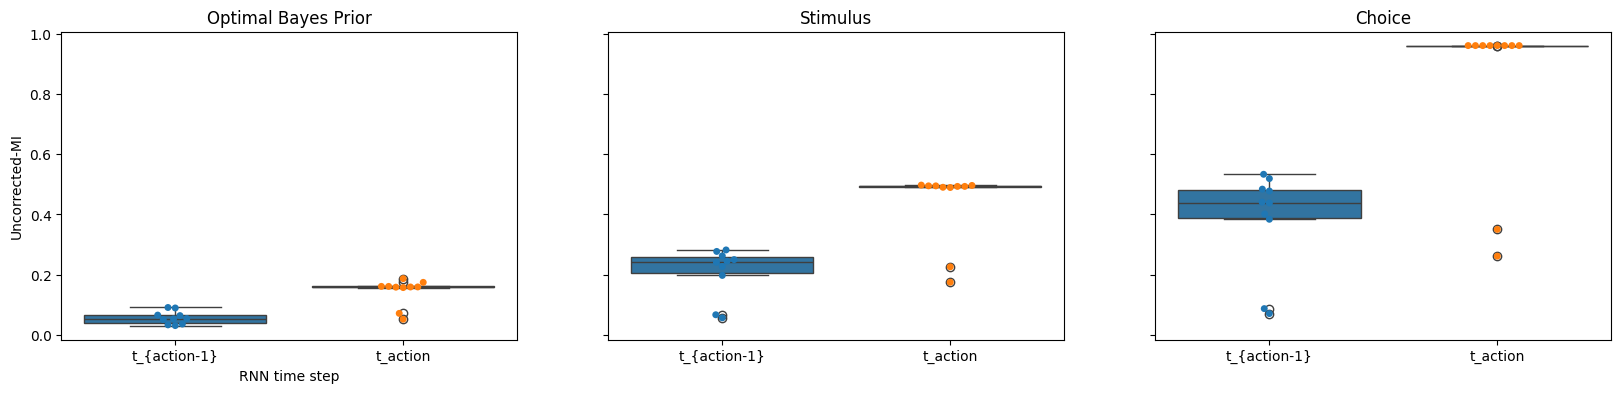

In [188]:
action_scores = np.stack([np.mean(test_scores_action_fold_t1_non_zero, axis=0),np.mean(test_scores_action_fold_tend, axis=0)], axis=1)
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_t1_non_zero, axis=0),np.mean(test_scores_trial_fold_tend, axis=0)], axis=1)
bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_t1_non_zero, axis=0),np.mean(test_scores_bayesian_fold_tend, axis=0)], axis=1)

fig, ax = plt.subplots(ncols=3, figsize=(20, 4), sharey=True, sharex=True)

sns.boxplot(bayesian_scores,ax=ax[0])
sns.swarmplot(bayesian_scores,ax=ax[0])

sns.boxplot(stimulus_scores,ax=ax[1])
sns.swarmplot(stimulus_scores,ax=ax[1])

sns.boxplot(action_scores,ax=ax[2])
sns.swarmplot(action_scores,ax=ax[2])


ax[0].set_xticks(np.arange(2),labels=['t_{action-1}','t_action'])
ax[0].set_xlabel('RNN time step')
ax[0].set_ylabel('Uncorrected-MI')
ax[0].set_title('Optimal Bayes Prior')
ax[1].set_title('Stimulus')
ax[2].set_title('Choice')

In [189]:
hidden_state_t_zero_contrast_correct = np.concatenate(t_zero_contrast.loc[correct_zero_contrast]['hidden_state'].values)
hidden_state_t_zero_contrast_incorrect = np.concatenate(t_zero_contrast.loc[incorrect_zero_contrast]['hidden_state'].values)

In [190]:

print('choice representation')
target = t_zero_contrast.loc[correct_zero_contrast]['action_side'].values
_, test_scores_action_fold_tzero_contrast_correct, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_correct, target)

target = t_zero_contrast.loc[incorrect_zero_contrast]['action_side'].values
_, test_scores_action_fold_tzero_contrast_incorrect, optimal_bins_tend_action = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_incorrect, target)



print('stimulus representation')
target = t_zero_contrast.loc[correct_zero_contrast]['trial_side'].values
_, test_scores_trial_fold_tzero_contrast_correct, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_correct, target)

target = t_zero_contrast.loc[incorrect_zero_contrast]['trial_side'].values
_, test_scores_trial_fold_tzero_contrast_incorrect, optimal_bins_tend_trial = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_incorrect, target)


print('prior representation')

target = t_zero_contrast.loc[correct_zero_contrast]['Bayes'].values
_, test_scores_bayesian_fold_tzero_contrast_correct, optimal_bins_tzero_contrast_correct_bayesian = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_correct, target)

target =  t_zero_contrast.loc[incorrect_zero_contrast]['Bayes'].values
_, test_scores_bayesian_fold_tzero_contrast_incorrect, optimal_bins_tzero_contrast_incorrect_bayesian = find_optimal_discretization_kfold(hidden_state_t_zero_contrast_incorrect, target)


choice representation


5it [00:00, 11.79it/s]
5it [00:00, 14.74it/s]


stimulus representation


5it [00:00, 12.84it/s]
5it [00:00, 13.93it/s]


prior representation


5it [00:00, 12.38it/s]
5it [00:00, 15.11it/s]


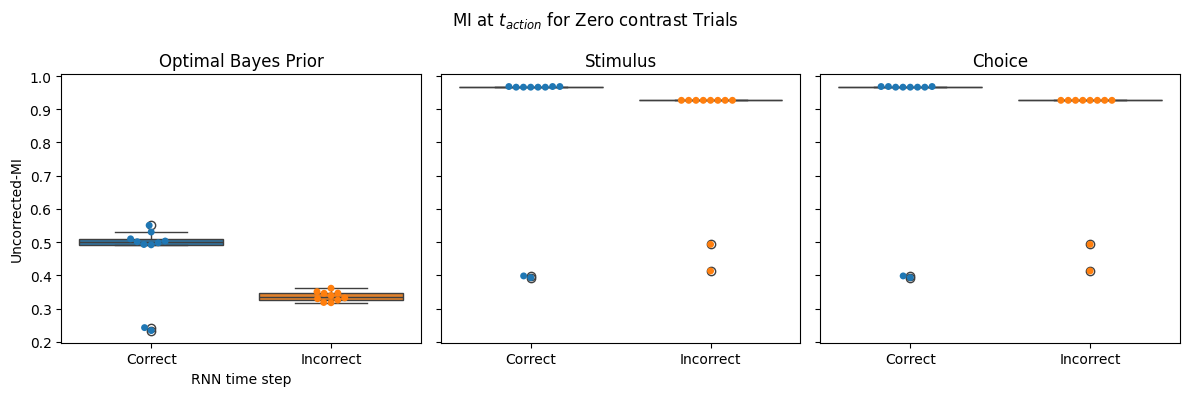

In [191]:
action_scores = np.stack([np.mean(test_scores_action_fold_tzero_contrast_correct, axis=0),np.mean(test_scores_action_fold_tzero_contrast_incorrect, axis=0)], axis=1)
stimulus_scores = np.stack([np.mean(test_scores_trial_fold_tzero_contrast_correct, axis=0),np.mean(test_scores_trial_fold_tzero_contrast_incorrect, axis=0)], axis=1)
bayesian_scores = np.stack([np.mean(test_scores_bayesian_fold_tzero_contrast_correct, axis=0),np.mean(test_scores_bayesian_fold_tzero_contrast_incorrect, axis=0)], axis=1)

fig, ax = plt.subplots(ncols=3, figsize=(12, 4), sharey=True, sharex=True)

sns.boxplot(bayesian_scores,ax=ax[0])
sns.swarmplot(bayesian_scores,ax=ax[0])

sns.boxplot(stimulus_scores,ax=ax[1])
sns.swarmplot(stimulus_scores,ax=ax[1])

sns.boxplot(action_scores,ax=ax[2])
sns.swarmplot(action_scores,ax=ax[2])


ax[0].set_xticks(np.arange(2),labels=['Correct','Incorrect'])
ax[0].set_xlabel('RNN time step')
ax[0].set_ylabel('Uncorrected-MI')
ax[0].set_title('Optimal Bayes Prior')
ax[1].set_title('Stimulus')
ax[2].set_title('Choice')
plt.suptitle('MI at $t_{action}$ for Zero contrast Trials')

plt.tight_layout()

In [192]:
### now for PID, set value at particular level

# run all PID

# organize everything; discretize separately, and then make plots
# all decisions

def get_all_pid(session_data,bayes_signal, indices,subset_bayes=False):

    iloc = np.where((session_data['action_taken'] == 1)==True)[0]
    t_1 = session_data.iloc[iloc-1][['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]

    t_0 = session_data.loc[session_data['trial_start'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
    t_0['signed_trial_strength'] /= t_0['signed_trial_strength'].max()

    t_end = session_data.loc[session_data['action_taken'] == 1,['block_side', 'signed_trial_strength', 'action_side','trial_side','correct_action_taken','hidden_state','left_stimulus','right_stimulus']]
    t_end['signed_trial_strength'] /= t_end['signed_trial_strength'].max()

    hidden_state_t_0 = np.concatenate(t_0['hidden_state'].values)
    hidden_state_t_1 = np.concatenate(t_1['hidden_state'].values)
    hidden_state_t_end = np.concatenate(t_end['hidden_state'].values)

    # discretize
    discretized_hidden_state_t_0 = discretize_hidden_state(hidden_state_t_0.T)
    discretized_hidden_state_t_1 = discretize_hidden_state(hidden_state_t_1.T)
    discretized_hidden_state_t_end = discretize_hidden_state(hidden_state_t_end.T)


    # compute all mutual informations

    # for t0 and t-1, no action

    
    pid_information, coinformation_data = compute_information_decomposition(t_0['trial_side'].values,  discretized_hidden_state_t_0)
    trial_side_t0 = np.hstack([pid_information, coinformation_data])


    pid_information, coinformation_data = compute_information_decomposition(t_0['block_side'].values,  discretized_hidden_state_t_0)
    block_side_t0 = np.hstack([pid_information, coinformation_data])
    

    pid_information, coinformation_data = compute_information_decomposition(t_1['trial_side'].values,  discretized_hidden_state_t_1)
    trial_side_t1 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_1['block_side'].values,  discretized_hidden_state_t_1)
    block_side_t1 = np.hstack([pid_information, coinformation_data])


    # for tend, compute all


    pid_information, coinformation_data = compute_information_decomposition(t_end['trial_side'].values,  discretized_hidden_state_t_end)
    trial_side_tend = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_end['block_side'].values,  discretized_hidden_state_t_end)
    block_side_tend = np.hstack([pid_information, coinformation_data])


    # action

    pid_information, coinformation_data = compute_information_decomposition(t_end['action_side'].values,  discretized_hidden_state_t_0)
    action_side_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_end['action_side'].values,  discretized_hidden_state_t_1)
    action_side_t1 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(t_end['action_side'].values,  discretized_hidden_state_t_end)
    action_side_tend = np.hstack([pid_information, coinformation_data])


    # compute bayes and hidden state for all
    if subset_bayes:
        bayes_signal = bayes_signal[indices]
    
    pid_information, coinformation_data = compute_information_decomposition(bayes_signal,  discretized_hidden_state_t_0)
    bayesian_t0 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(bayes_signal,  discretized_hidden_state_t_1)
    bayesian_t1 = np.hstack([pid_information, coinformation_data])

    pid_information, coinformation_data = compute_information_decomposition(bayes_signal,  discretized_hidden_state_t_end)
    bayesian_tend = np.hstack([pid_information, coinformation_data])

    # compute means for different catagories, and then plot them
    # we could do this stacking, but maybe after computing the means

    trial_side_t0_mean = np.mean(trial_side_t0, axis=0)
    block_side_t0_mean = np.mean(block_side_t0, axis=0)
    trial_side_t1_mean = np.mean(trial_side_t1, axis=0)
    block_side_t1_mean = np.mean(block_side_t1, axis=0)
    trial_side_tend_mean = np.mean(trial_side_tend, axis=0)
    block_side_tend_mean = np.mean(block_side_tend, axis=0)
    action_side_t0_mean = np.mean(action_side_t0, axis=0)
    action_side_t1_mean = np.mean(action_side_t1, axis=0)
    action_side_tend_mean = np.mean(action_side_tend, axis=0)
    bayesian_t0_mean = np.mean(bayesian_t0, axis=0)
    bayesian_t1_mean = np.mean(bayesian_t1, axis=0)
    bayesian_tend_mean = np.mean(bayesian_tend, axis=0)

    trial_side_t0_std = np.std(trial_side_t0, axis=0)
    block_side_t0_std = np.std(block_side_t0, axis=0)
    trial_side_t1_std = np.std(trial_side_t1, axis=0)
    block_side_t1_std = np.std(block_side_t1, axis=0)
    trial_side_tend_std = np.std(trial_side_tend, axis=0)
    block_side_tend_std = np.std(block_side_tend, axis=0)
    action_side_t0_std = np.std(action_side_t0, axis=0)
    action_side_t1_std = np.std(action_side_t1, axis=0)
    action_side_tend_std = np.std(action_side_tend, axis=0)
    bayesian_t0_std = np.std(bayesian_t0, axis=0)
    bayesian_t1_std = np.std(bayesian_t1, axis=0)
    bayesian_tend_std = np.std(bayesian_tend, axis=0)

    # maybe it makes more sense to plot the activity of each unit rather than the 


    Bayesian_mean_stack = np.stack([bayesian_t0_mean,bayesian_t1_mean,bayesian_tend_mean],axis=1)
    Block_side_mean_stack = np.stack([block_side_t0_mean,block_side_t1_mean,block_side_tend_mean],axis=1)
    Stim_side_mean_stack = np.stack([trial_side_t0_mean,trial_side_t1_mean,trial_side_tend_mean],axis=1)
    Action_side_mean_stack = np.stack([action_side_t0_mean,action_side_t1_mean,action_side_tend_mean],axis=1)


    Bayesian_std_stack = np.stack([bayesian_t0_std,bayesian_t1_std,bayesian_tend_std],axis=1)
    Block_side_std_stack = np.stack([block_side_t0_std,block_side_t1_std,block_side_tend_std],axis=1)
    Stim_side_std_stack = np.stack([trial_side_t0_std,trial_side_t1_std,trial_side_tend_std],axis=1)
    Action_side_std_stack = np.stack([action_side_t0_std,action_side_t1_std,action_side_tend_std],axis=1)

    fig, ax = plt.subplots(figsize=(20,4), ncols=4, sharey=True, sharex=True)

    ax[0].bar(np.arange(3)-0.25,Bayesian_mean_stack[2,:],width=0.25, yerr=Bayesian_std_stack[2,:]/2)
    ax[0].bar(np.arange(3),Bayesian_mean_stack[3,:],width=0.25, yerr=Bayesian_std_stack[3,:]/2)
    ax[0].bar(np.arange(3)+0.25,Bayesian_mean_stack[-1,:],width=0.25, yerr=Bayesian_std_stack[-1,:]/2)
    ax[0].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[0].set_xlabel('RNN time step')
    ax[0].set_ylabel('Bits')
    ax[0].set_title('Optimal Bayes Prior Representation')


    ax[1].bar(np.arange(3)-0.25,Block_side_mean_stack[2,:],width=0.25, yerr=Block_side_std_stack[2,:]/2)
    ax[1].bar(np.arange(3),Block_side_mean_stack[3,:],width=0.25, yerr=Block_side_std_stack[3,:]/2)
    ax[1].bar(np.arange(3)+0.25,Block_side_mean_stack[-1,:],width=0.25, yerr=Block_side_std_stack[-1,:]/2)
    ax[1].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[1].set_xlabel('RNN time step')
    ax[1].set_title('Block Side Representation')


    ax[2].bar(np.arange(3)-0.25,Stim_side_mean_stack[2,:],width=0.25, yerr=Stim_side_std_stack[2,:]/2)
    ax[2].bar(np.arange(3),Stim_side_mean_stack[3,:],width=0.25, yerr=Stim_side_std_stack[3,:]/2)
    ax[2].bar(np.arange(3)+0.25,Stim_side_mean_stack[-1,:],width=0.25, yerr=Stim_side_std_stack[-1,:]/2)
    ax[2].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[2].set_xlabel('RNN time step')
    ax[2].set_title('Stim Side Representation')



    ax[3].bar(np.arange(3)-0.25,Action_side_mean_stack[2,:],width=0.25, yerr=Action_side_std_stack[2,:]/2,label='Redundancy')
    ax[3].bar(np.arange(3),Action_side_mean_stack[3,:],width=0.25, yerr=Action_side_std_stack[3,:]/2,label='Synergy')
    ax[3].bar(np.arange(3)+0.25,Action_side_mean_stack[-1,:],width=0.25, yerr=Action_side_std_stack[-1,:]/2,label='total MI')
    ax[3].set_xticks(np.arange(3),labels=['t0','t-1','t_action'])
    ax[3].set_xlabel('RNN time step')
    ax[3].set_title('Choice Side Representation')

    plt.legend()
    
    return (Bayesian_mean_stack, Block_side_mean_stack, Stim_side_mean_stack, Action_side_mean_stack, Bayesian_std_stack, Block_side_std_stack, Stim_side_std_stack, Action_side_std_stack)

In [193]:
bayes_signal = t_1['Bayes']

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 881.90it/s]


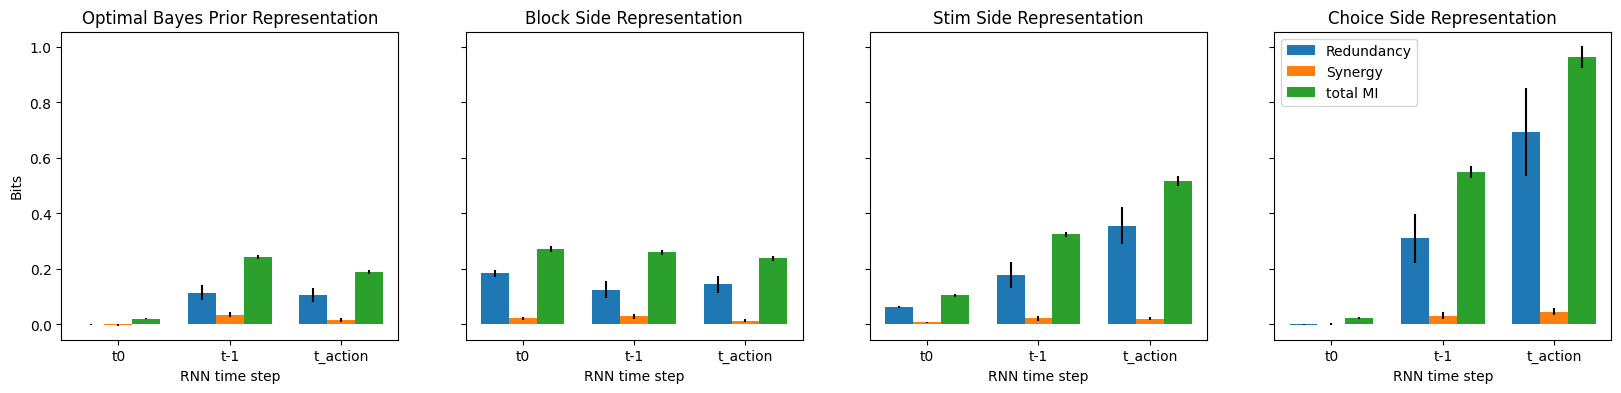

In [194]:
(Bayesian_mean_stack, Block_side_mean_stack, Stim_side_mean_stack, Action_side_mean_stack, Bayesian_std_stack, Block_side_std_stack, Stim_side_std_stack, Action_side_std_stack) = get_all_pid(session_data, bayes_signal,[], False)